In [6]:
import sys
import matplotlib.pyplot as plt
from pathlib import Path

In [7]:
# --------------- Set up project root path  --------------- #
project_folder_name = "MFC2024" # Set this to the name of your project root folderS
project_root = next((p for p in [Path.cwd(), *Path.cwd().parents] if p.name == project_folder_name), None)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
# --------------- Import custom modules  --------------- #
from model.static import PEMFC_stat
from model.coefficients import *
from config.initialize import *
from config.settings import *

In [8]:
I_points = [10,20,30,40,50]

stat_sim_log = {}
for P_des in [1.3,1.4,1.5]:
    for T_des in [323.15,333.15,343.15]:
        states_stat = []
        Ucell_stat = []
        print(f"Simulating for RHC={0.5}, P_des={P_des} bar, T_des={T_des} K...")
        for I_LOAD in I_points:
            # --------------- Steady-state Simulation  --------------- #
            operating_inputs_stat = operating_inputs.copy()
            Wout_c = 20 + I_LOAD * 1.
            Win_c = 10 + I_LOAD *1.8
            operating_inputs_stat = {'Tfc': T_des, 'Phi_a_des': 0.0, 'Phi_c_des': 0.5,
                                                    'Pa_des': P_des * 1e5, 'Pc_des': P_des * 1e5,
                                                    'Win_c': Win_c, 'Wout_c': Wout_c, 'Win_a': 4.8, 'Wout_a': 4.8}
            model = PEMFC_stat(parameters,operating_inputs_stat)
            sol = model.solve(I_LOAD/parameters['Aact'])
            # --------------- Log states for steady-state simulation  --------------- #
            states_stat.append(sol)
        
        # --------------- Log states for both simulations  --------------- #
        stat_sim_log["RHA"+str(0)+"/RHC" + str(0.5) + "_P" + str(P_des) + "_T" + str(T_des)] = {"states":states_stat}

Simulating for RHC=0.5, P_des=1.3 bar, T_des=323.15 K...
Simulating for RHC=0.5, P_des=1.3 bar, T_des=333.15 K...
Simulating for RHC=0.5, P_des=1.3 bar, T_des=343.15 K...
Simulating for RHC=0.5, P_des=1.4 bar, T_des=323.15 K...
Simulating for RHC=0.5, P_des=1.4 bar, T_des=333.15 K...
Simulating for RHC=0.5, P_des=1.4 bar, T_des=343.15 K...
Simulating for RHC=0.5, P_des=1.5 bar, T_des=323.15 K...
Simulating for RHC=0.5, P_des=1.5 bar, T_des=333.15 K...
Simulating for RHC=0.5, P_des=1.5 bar, T_des=343.15 K...


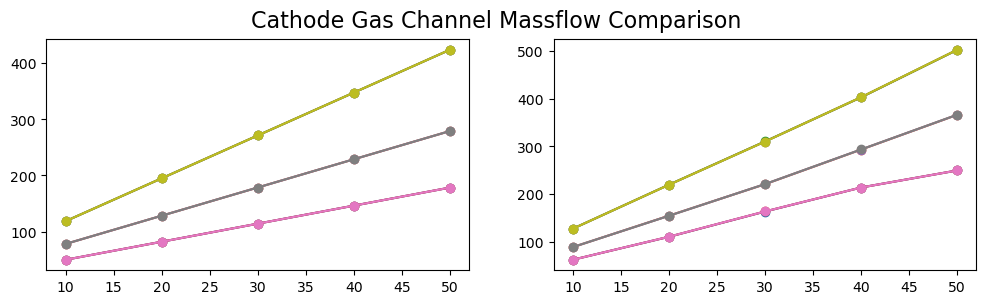

In [9]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 3))
fig.suptitle("Cathode Gas Channel Massflow Comparison", fontsize=16)

# DEB_H2O [NL/min] → mol/(m³·s)
# NL/min → m³/s: ×1e-3/60 ; m³/s → mol/s: ÷Vm_STP ; mol/s → mol/(m³·s): ÷V_gc_total
Vm_STP = R * 273.15 / 101325  # m³/mol at standard conditions (0°C, 1 atm)
V_gc_total = n_cell * parameters["Hgc"] * parameters["Wgc"] * parameters["Lgc"]
conv_DEB_H2O = 1e-3 / 60 / Vm_STP / V_gc_total  # (mol/m³/s) per (NL/min)

for key in stat_sim_log.keys():
    states_stat = stat_sim_log[key]["states"]
    # Dynamic vs static model results
    axes[0].plot(I_points, [states["Jv_c_in"] for states in states_stat], label=key, marker='o')
    axes[1].plot(I_points, [states["Jv_c_out"] for states in states_stat], label=key, marker='o')

### Steady-State Results
- **$\lambda_{acl}$ / $\lambda_{ccl}$**: Water content at the anode / cathode catalyst layer
- **$C_{v,acl}$ / $C_{v,ccl}$**: Vapor concentration at the anode / cathode catalyst layer (mol/m³)
- **$J_{w,an}$ / $J_{w,ca}$**: Water flux in the anode / cathode GDL (mol/m²s)
- **$s_{agdl}$ / $s_{cgdl}$**: Saturation profile in the anode / cathode GDL, with vertical dashed lines at the saturation front ($x_{front}$)

## GUI-style polarization presentation
Mirrors the Streamlit GUI output for a polarization profile run in Static mode (single polar curve), plus the spatial profile across the MEA at the highest tested current.


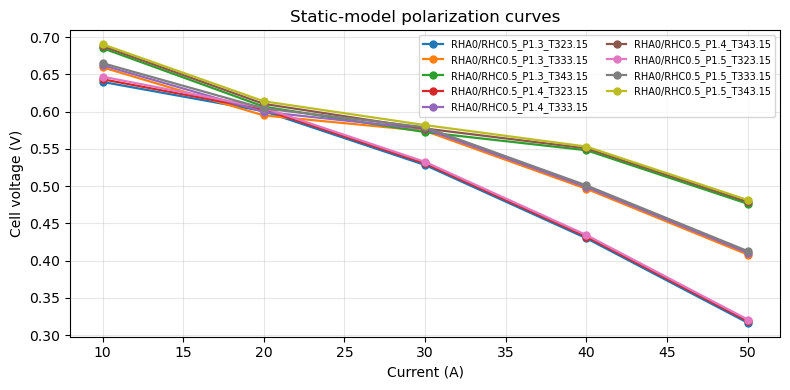

In [10]:
# Polar curve (Ucell vs I) -- the GUI's static-mode output,
# rebuilt from the per-current `model.solve(i)` result dicts.
fig, ax = plt.subplots(figsize=(8, 4))
for cond_key, group in stat_sim_log.items():
    Ucell_curve = []
    for I, sol_i in zip(I_points, group["states"]):
        i_density = I / parameters["Aact"]
        Ucell_curve.append(sol_i["Ueq"] - sol_i["eta_c"]
                           - i_density * (sol_i["Rohm"] + sol_i["Rccl"] + sol_i["Racl"]))
    ax.plot(I_points, Ucell_curve, marker="o", linewidth=1.6, markersize=5, label=cond_key)
ax.set_title("Static-model polarization curves")
ax.set_xlabel("Current (A)")
ax.set_ylabel("Cell voltage (V)")
ax.legend(fontsize=7, loc="best", ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


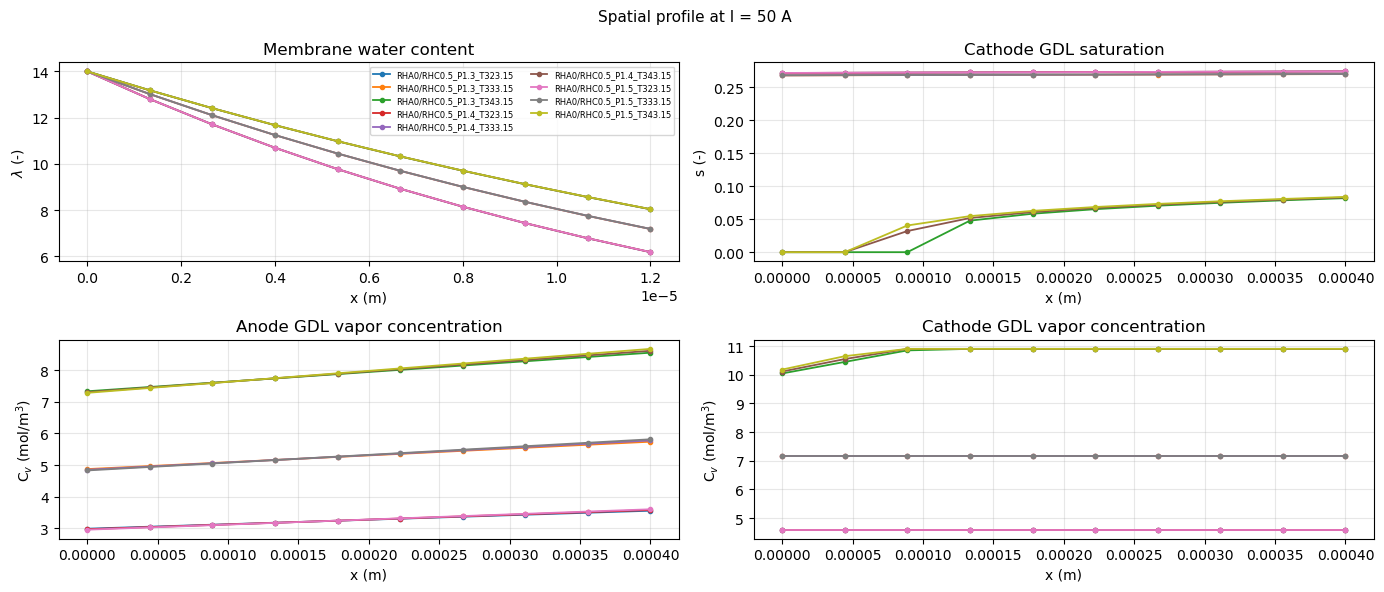

In [11]:
# Spatial profile across the MEA at the highest tested current.
# Static `model.solve(i)` returns lambda_mem / s_agdl / s_cgdl / C_v_agdl /
# C_v_cgdl as per-node arrays.
import numpy as np

last_idx = len(I_points) - 1
fig, axes = plt.subplots(figsize=(14, 6), nrows=2, ncols=2)

x_mem  = np.linspace(0, parameters["Hmem"], 10)
x_agdl = np.linspace(0, parameters["Hgdl"], 10)
x_cgdl = np.linspace(0, parameters["Hgdl"], 10)

for cond_key, group in stat_sim_log.items():
    sol_i = group["states"][last_idx]
    axes[0, 0].plot(x_mem,  sol_i["lambda_mem"], marker="o", label=cond_key, linewidth=1.3, markersize=3)
    axes[0, 1].plot(x_cgdl, sol_i["s_cgdl"],     marker="o", label=cond_key, linewidth=1.3, markersize=3)
    axes[1, 0].plot(x_agdl, sol_i["C_v_agdl"],   marker="o", label=cond_key, linewidth=1.3, markersize=3)
    axes[1, 1].plot(x_cgdl, sol_i["C_v_cgdl"],   marker="o", label=cond_key, linewidth=1.3, markersize=3)

axes[0, 0].set_title("Membrane water content");          axes[0, 0].set_ylabel(r"$\lambda$ (-)")
axes[0, 1].set_title("Cathode GDL saturation");          axes[0, 1].set_ylabel("s (-)")
axes[1, 0].set_title("Anode GDL vapor concentration");   axes[1, 0].set_ylabel("C$_v$ (mol/m$^3$)")
axes[1, 1].set_title("Cathode GDL vapor concentration"); axes[1, 1].set_ylabel("C$_v$ (mol/m$^3$)")
for ax in axes.flatten():
    ax.set_xlabel("x (m)")
    ax.grid(True, alpha=0.3)
axes[0, 0].legend(fontsize=6, loc="best", ncol=2)
fig.suptitle(f"Spatial profile at I = {I_points[-1]} A", fontsize=11)
plt.tight_layout()
plt.show()
